# Analyse des Concentrations de Planctons Marins
## Jalon 2/3 : Nouvelles Représentations de Données


---

### Résumé
Ce notebook constitue le deuxième jalon du projet. Il explore des méthodes de représentation
alternatives à l'ACP : l'Analyse Factorielle des Correspondances (AFC), Isomap, LLE et MDS.
Les résultats du Jalon 1 sont chargés via un fichier pickle (`data/jalon1_outputs.pkl`).


## Table des matières

1. [Chargement des résultats Jalon 1](#chargement)
2. [AFC : Analyse Factorielle des Correspondances](#afc)
3. [Isomap](#isomap)
4. [LLE : Locally Linear Embedding](#lle)
5. [MDS : Multidimensional Scaling](#mds)
6. [Comparaison des représentations](#comparaison)
7. [Sauvegarde des résultats](#sauvegarde)
8. [Conclusions & Perspectives](#conclusions)


<a id="chargement"></a>

---

## 1. Chargement des résultats Jalon 1


In [1]:
# === Chargement des résultats Jalon 1 ===
import pickle

with open('data/jalon1_outputs.pkl', 'rb') as f:
    _d = pickle.load(f)

df            = _d['df']
df_hellinger  = _d['df_hellinger']
COLS_CONC     = _d['COLS_CONC']
COLS_ENV      = _d['COLS_ENV']
X_pca         = _d['X_pca']
n_80          = _d['n_80']
pca           = _d['pca']
labels_final  = _d['labels_final']
K_OPTIMAL     = _d['K_OPTIMAL']
unique_layers = _d['unique_layers']
X_hell        = df_hellinger.values

# Fallbacks for variables that might be missing in older pickle files
pc1_var = _d.get('pc1_var', pca.explained_variance_ratio_[0] * 100)
pc2_var = _d.get('pc2_var', pca.explained_variance_ratio_[1] * 100)

print(f"Données Jalon 1 chargées — {X_pca.shape[0]} obs, {n_80} composantes PCA")


Données Jalon 1 chargées — 4264 obs, 9 composantes PCA


In [2]:
# === Imports Jalon 2 ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.manifold import Isomap, LocallyLinearEmbedding, MDS
from sklearn.metrics import silhouette_score as sil_score, pairwise_distances as pw_dist
from sklearn.preprocessing import LabelEncoder

# Constants from Jalon 1
RANDOM_STATE = 42

# Fallback definition for cluster_colors if not in pickle
cluster_colors = _d.get('cluster_colors', plt.cm.Set1(np.linspace(0, 0.9, K_OPTIMAL)))


## 2.1 AFC : Analyse Factorielle des Correspondances (Benzécri, 1973)

L'AFC est une méthode factorielle adaptée aux **tableaux de fréquences ou de composition**. Elle représente simultanément les individus (échantillons) et les variables (groupes planctoniques) dans un même espace factoriel : c'est le **biplot**.

**Différence avec l'ACP** : L'AFC utilise la **distance du χ² pondérée** par les masses marginales, ce qui est plus adapté aux données de composition (abondances relatives). Un individu proche d'une espèce dans le biplot indique une forte occurrence relative de ce groupe.

**Algorithme** : Décomposition en valeurs singulières de la matrice des résidus χ² standardisés :

$$S_{ij} = \frac{p_{ij} - r_i c_j}{\sqrt{r_i c_j}}$$

où $p_{ij} = n_{ij}/N$, $r_i = \sum_j p_{ij}$ (masse ligne), $c_j = \sum_i p_{ij}$ (masse colonne).

In [3]:
# === AFC — Implémentation via SVD ===

def correspondence_analysis(X, n_components=2):
    """AFC via décomposition SVD de la matrice des résidus chi2 standardisés."""
    X = np.maximum(X.astype(float), 0)
    N = X.sum()
    if N == 0:
        raise ValueError("Tableau vide.")
    P   = X / N                         # Fréquences relatives
    r   = P.sum(axis=1)                 # Masses lignes
    c   = P.sum(axis=0)                 # Masses colonnes
    r_s = np.where(r > 1e-15, r, 1e-15)
    c_s = np.where(c > 1e-15, c, 1e-15)
    Dr_inv = np.diag(r_s ** -0.5)
    Dc_inv = np.diag(c_s ** -0.5)
    S = Dr_inv @ (P - np.outer(r, c)) @ Dc_inv   # Résidus chi2 standardisés
    U, sv, Vt = np.linalg.svd(S, full_matrices=False)
    F = Dr_inv @ U[:, :n_components] * sv[:n_components]   # Coord. principales lignes
    G = Dc_inv @ Vt[:n_components].T * sv[:n_components]   # Coord. principales colonnes
    inertia  = sv ** 2
    explained = inertia / inertia.sum()
    return F, G, explained, sv

# Données brutes (non-négatives, NA → 0)
X_afc_raw = df[COLS_CONC].fillna(0).values

t0 = time.time()
F_afc, G_afc, afc_explained, afc_sv = correspondence_analysis(X_afc_raw, n_components=2)
t_afc = time.time() - t0

afc_ax1  = afc_explained[0] * 100
afc_ax2  = afc_explained[1] * 100
afc_cum2 = afc_ax1 + afc_ax2

print('=== Résultats AFC ===')
print(f'Temps de calcul  : {t_afc:.2f}s')
print(f'Inertie totale (χ²/N) : {(afc_sv**2).sum():.6f}')
print(f'Axe 1 : {afc_ax1:.2f}%')
print(f'Axe 2 : {afc_ax2:.2f}%')
print(f'Axes 1+2 cumulés : {afc_cum2:.2f}%')
print(f'Shape F (individus) : {F_afc.shape} | G (variables) : {G_afc.shape}')

=== Résultats AFC ===
Temps de calcul  : 0.08s
Inertie totale (χ²/N) : 6.614577
Axe 1 : 15.07%
Axe 2 : 12.78%
Axes 1+2 cumulés : 27.85%
Shape F (individus) : (4264, 2) | G (variables) : (28, 2)


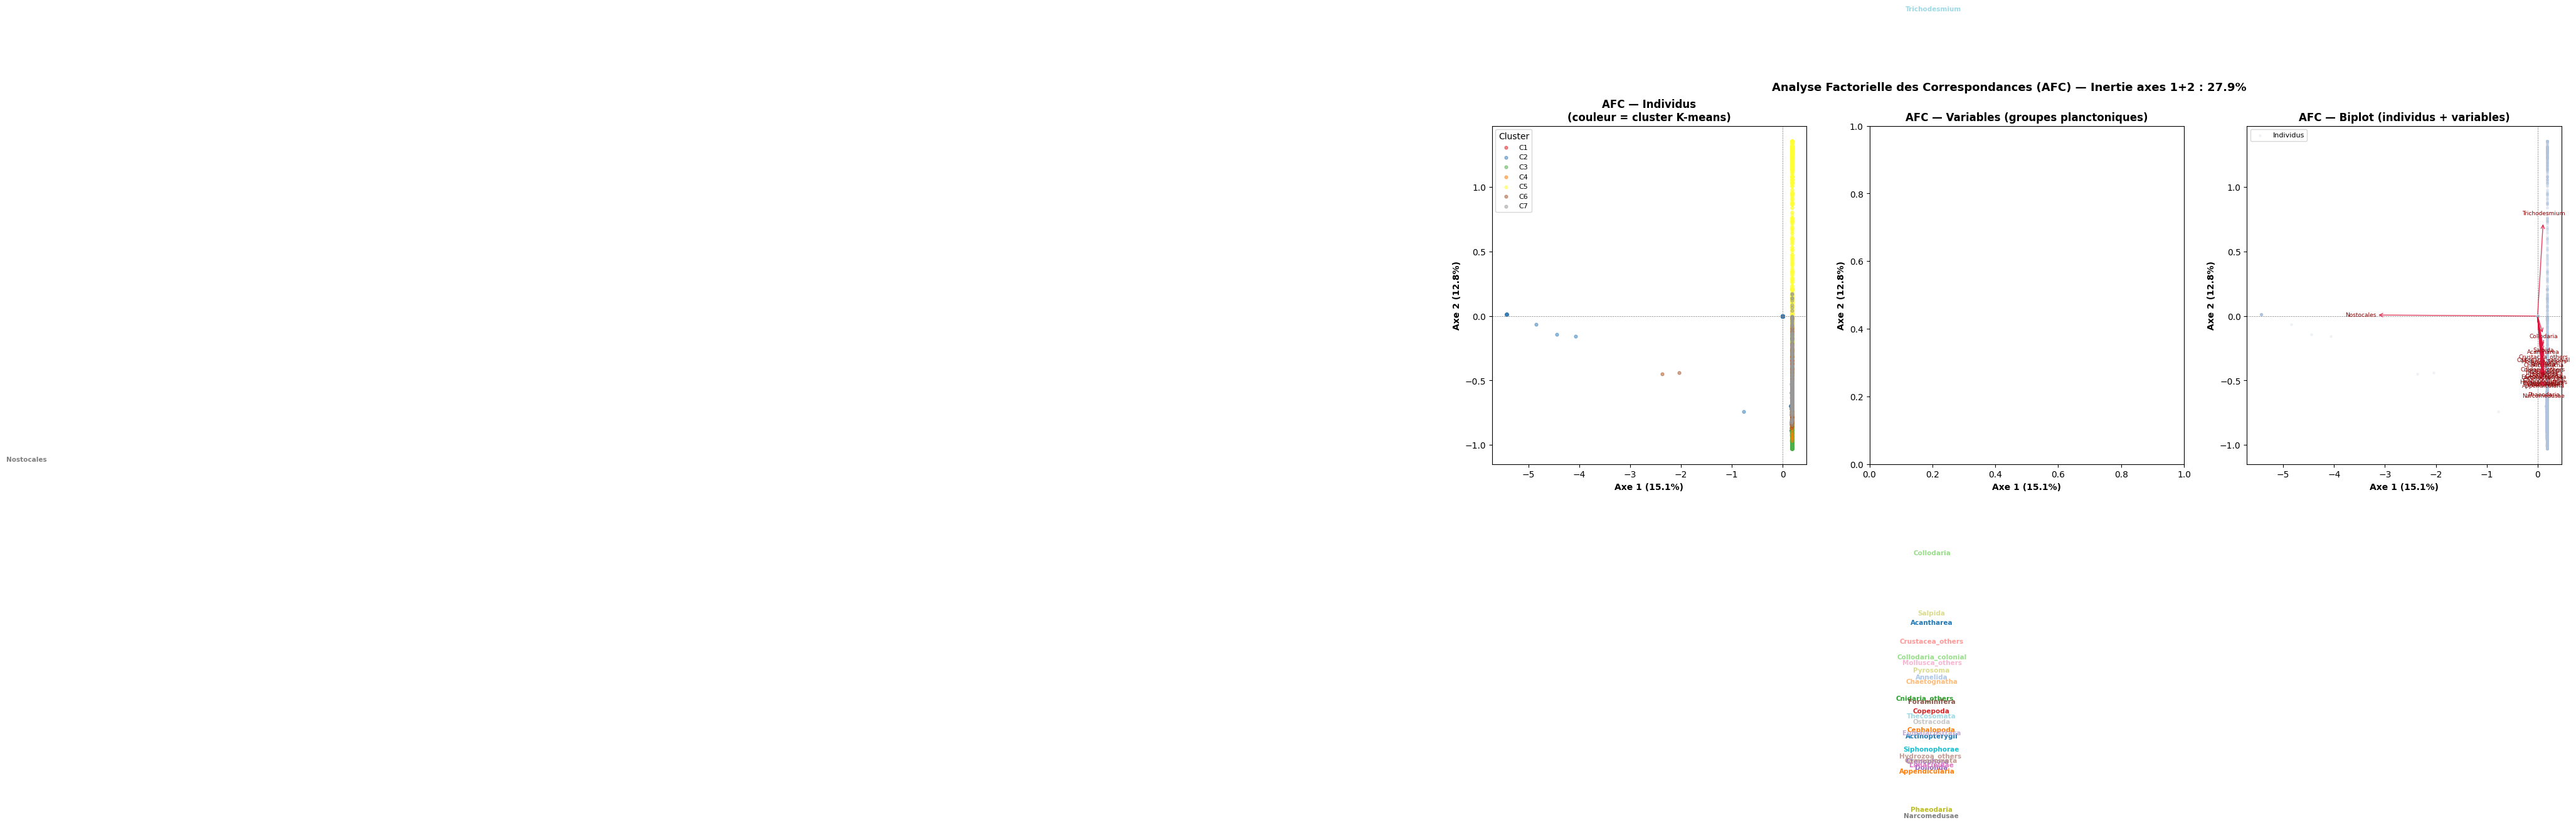

In [4]:
# === Visualisation AFC ===

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- 1. Individus — couleur cluster baseline ---
for c in range(K_OPTIMAL):
    mask = labels_final == c
    axes[0].scatter(F_afc[mask, 0], F_afc[mask, 1],
                    s=12, alpha=0.5, color=cluster_colors[c], label=f'C{c+1}')
axes[0].set_xlabel(f'Axe 1 ({afc_ax1:.1f}%)', fontweight='bold')
axes[0].set_ylabel(f'Axe 2 ({afc_ax2:.1f}%)', fontweight='bold')
axes[0].set_title('AFC — Individus\n(couleur = cluster K-means)', fontweight='bold')
axes[0].legend(title='Cluster', fontsize=8)
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].axvline(0, color='gray', lw=0.5, ls='--')

# --- 2. Variables (groupes planctoniques) ---
colors_sp = plt.cm.tab20(np.linspace(0, 1, len(COLS_CONC)))
for i, (col, xy) in enumerate(zip(COLS_CONC, G_afc)):
    x, y = xy
    axes[1].annotate('', xy=(x, y), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colors_sp[i], lw=1.2))
    axes[1].text(x * 1.08, y * 1.08, col, fontsize=7.5, color=colors_sp[i],
                 fontweight='bold', ha='center', va='center')
axes[1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].axvline(0, color='gray', lw=0.5, ls='--')
axes[1].set_xlabel(f'Axe 1 ({afc_ax1:.1f}%)', fontweight='bold')
axes[1].set_ylabel(f'Axe 2 ({afc_ax2:.1f}%)', fontweight='bold')
axes[1].set_title('AFC — Variables (groupes planctoniques)', fontweight='bold')

# --- 3. Biplot combiné (individus + variables) ---
q_ind = np.percentile(np.abs(F_afc), 85) + 1e-12
q_var = np.percentile(np.abs(G_afc), 85) + 1e-12
scale = q_ind / q_var * 0.6

axes[2].scatter(F_afc[:, 0], F_afc[:, 1], s=6, alpha=0.15,
                color='lightsteelblue', label='Individus')
for i, (col, xy) in enumerate(zip(COLS_CONC, G_afc)):
    xs, ys = xy[0] * scale, xy[1] * scale
    axes[2].annotate('', xy=(xs, ys), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='crimson', lw=1.0, alpha=0.8))
    axes[2].text(xs * 1.1, ys * 1.1, col, fontsize=6.5, color='darkred',
                 ha='center', va='center')
axes[2].axhline(0, color='gray', lw=0.5, ls='--')
axes[2].axvline(0, color='gray', lw=0.5, ls='--')
axes[2].set_xlabel(f'Axe 1 ({afc_ax1:.1f}%)', fontweight='bold')
axes[2].set_ylabel(f'Axe 2 ({afc_ax2:.1f}%)', fontweight='bold')
axes[2].set_title('AFC — Biplot (individus + variables)', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle(f'Analyse Factorielle des Correspondances (AFC) — Inertie axes 1+2 : {afc_cum2:.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_afc.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.2 Isomap (Tenenbaum et al., 2000)

L'Isomap est une méthode **non-linéaire** qui généralise l'MDS en utilisant les **distances géodésiques** sur la variété des données (plutôt que les distances euclidiennes directes).

**Algorithme en 3 étapes** :
1. Construire le graphe des $k$ plus proches voisins
2. Calculer les distances géodésiques (chemin le plus court dans le graphe)
3. Appliquer l'MDS classique sur la matrice de distances géodésiques

**Paramètre clé** : `n_neighbors` : contrôle le compromis entre fidélité locale (petit $k$) et globale (grand $k$).  
**Mesure de qualité** : Erreur de reconstruction (plus faible = meilleure représentation).

In [5]:
# === Isomap — Optimisation du nombre de voisins ===

n_neighbors_range = [5, 10, 15, 20, 30]
isomap_results = {}

print('Optimisation Isomap (n_neighbors) :')
print(f'{"n_neighbors":>12} | {"Err. reconstruction":>20} | {"Temps (s)":>10}')
print('-' * 48)

for n_nbrs in n_neighbors_range:
    t0 = time.time()
    try:
        iso = Isomap(n_neighbors=n_nbrs, n_components=2, n_jobs=-1)
        X_iso_tmp = iso.fit_transform(X_hell)
        err = iso.reconstruction_error()
        t_iso = time.time() - t0
        isomap_results[n_nbrs] = {'embedding': X_iso_tmp, 'error': err, 'time': t_iso}
        print(f'{n_nbrs:>12} | {err:>20.4f} | {t_iso:>10.2f}')
    except Exception as e:
        print(f'{n_nbrs:>12} | Erreur : {str(e)[:35]}')

# Meilleur n_neighbors : minimise l'erreur de reconstruction
best_n_iso = min(isomap_results, key=lambda k: isomap_results[k]['error'])
X_isomap   = isomap_results[best_n_iso]['embedding']
t_isomap   = isomap_results[best_n_iso]['time']
iso_err    = isomap_results[best_n_iso]['error']

print(f'')
print(f'Meilleur n_neighbors = {best_n_iso} (err. reconstruction = {iso_err:.4f})')

Optimisation Isomap (n_neighbors) :
 n_neighbors |  Err. reconstruction |  Temps (s)
------------------------------------------------
           5 |               0.7798 |       4.96
          10 |               0.5493 |       3.99
          15 |               0.4792 |       4.76
          20 |               0.4406 |       5.34
          30 |               0.3797 |       6.23

Meilleur n_neighbors = 30 (err. reconstruction = 0.3797)


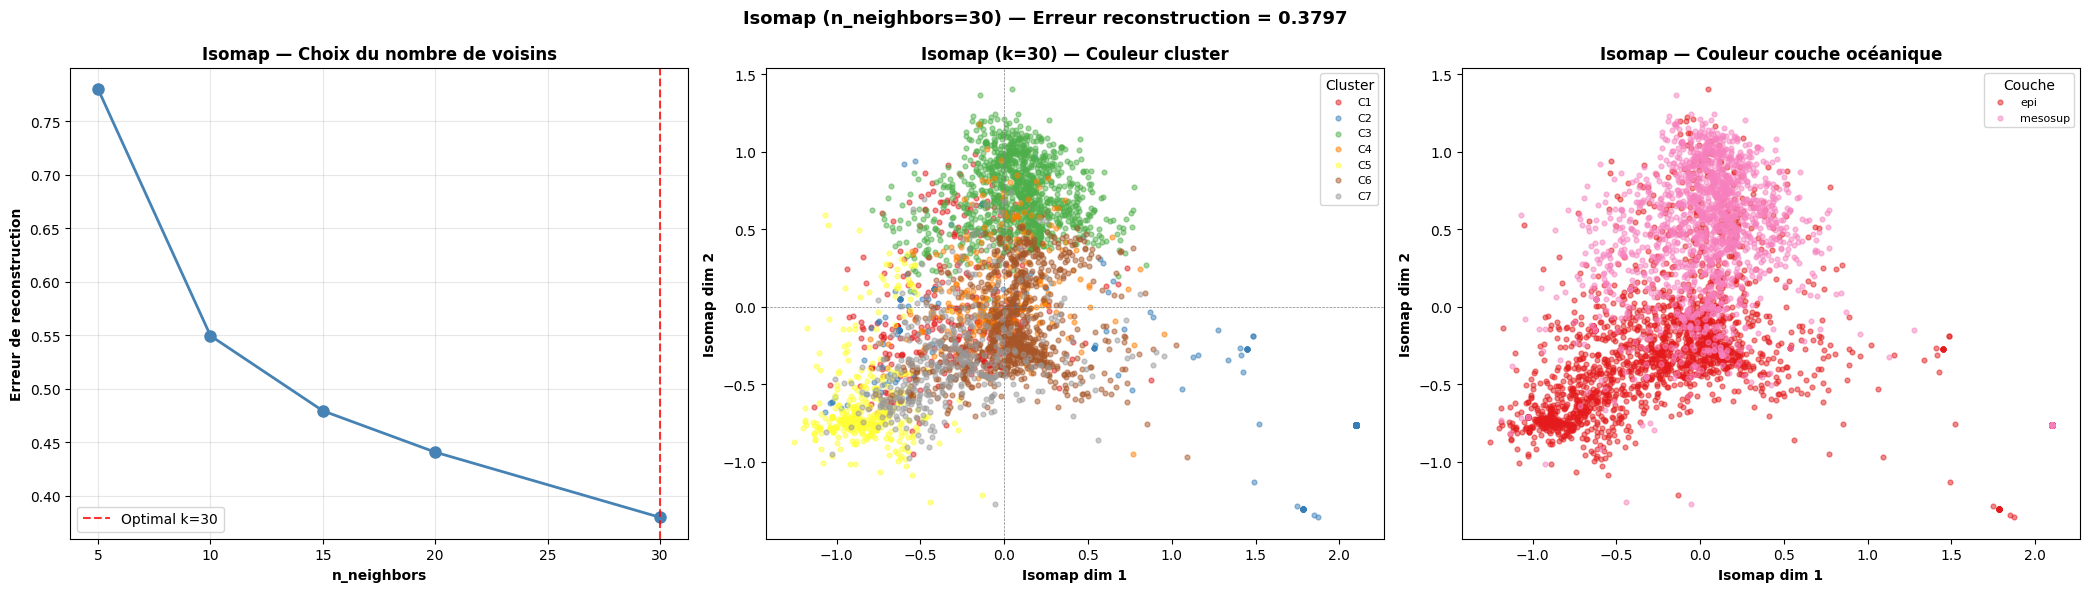

In [6]:
# === Isomap — Visualisation ===

# Palette couleurs par couche (réutilisée pour LLE et MDS)
unique_layers = sorted(df['layer'].dropna().unique())
cmap_layers   = plt.cm.Set1(np.linspace(0, 0.8, len(unique_layers)))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Courbe erreur de reconstruction
nbrs_list = sorted(isomap_results.keys())
errors_iso = [isomap_results[n]['error'] for n in nbrs_list]
axes[0].plot(nbrs_list, errors_iso, 'o-', color='steelblue', markersize=8, linewidth=2)
axes[0].axvline(best_n_iso, color='red', ls='--', alpha=0.8, label=f'Optimal k={best_n_iso}')
axes[0].set_xlabel('n_neighbors', fontweight='bold')
axes[0].set_ylabel('Erreur de reconstruction', fontweight='bold')
axes[0].set_title('Isomap — Choix du nombre de voisins', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Projection 2D — couleur cluster
for c in range(K_OPTIMAL):
    mask = labels_final == c
    axes[1].scatter(X_isomap[mask, 0], X_isomap[mask, 1],
                    s=12, alpha=0.5, color=cluster_colors[c], label=f'C{c+1}')
axes[1].set_xlabel('Isomap dim 1', fontweight='bold')
axes[1].set_ylabel('Isomap dim 2', fontweight='bold')
axes[1].set_title(f'Isomap (k={best_n_iso}) — Couleur cluster', fontweight='bold')
axes[1].legend(title='Cluster', fontsize=8)
axes[1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].axvline(0, color='gray', lw=0.5, ls='--')

# Projection 2D — couleur couche
for k, layer in enumerate(unique_layers):
    mask = df['layer'].values == layer
    axes[2].scatter(X_isomap[mask, 0], X_isomap[mask, 1],
                    s=12, alpha=0.5, color=cmap_layers[k], label=layer)
axes[2].set_xlabel('Isomap dim 1', fontweight='bold')
axes[2].set_ylabel('Isomap dim 2', fontweight='bold')
axes[2].set_title('Isomap — Couleur couche océanique', fontweight='bold')
axes[2].legend(title='Couche', fontsize=8)

plt.suptitle(f'Isomap (n_neighbors={best_n_iso}) — Erreur reconstruction = {iso_err:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_15_isomap.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.3 LLE : Locally Linear Embedding (Roweis & Saul, 2000)

Le LLE suppose que chaque point peut être **reconstruit linéairement** à partir de ses $k$ voisins les plus proches, et cherche à préserver ces poids de reconstruction dans l'espace réduit.

**Algorithme en 3 étapes** :
1. Trouver les $k$ plus proches voisins de chaque point
2. Calculer les poids de reconstruction locale (moindres carrés sous contrainte)
3. Chercher l'embedding de basse dimension qui minimise l'erreur de reconstruction globale

**Avantage** : Capture des géométries **locales** non-linéaires  
**Limite** : Sensible au bruit, instable pour les petits `n_neighbors`, sensible aux outliers

In [7]:
# === LLE — Optimisation du nombre de voisins ===

n_neighbors_lle = [5, 10, 15, 20]
lle_results = {}
t_lle_final = 0.0   # fallback
lle_err_final = 0.0
best_n_lle = 5

print('Optimisation LLE (n_neighbors, method=standard) :')
print(f'{"n_neighbors":>12} | {"Err. reconstruction":>20} | {"Temps (s)":>10}')
print('-' * 48)

for n_nbrs in n_neighbors_lle:
    t0 = time.time()
    try:
        lle = LocallyLinearEmbedding(
            n_neighbors=n_nbrs, n_components=2,
            method='standard', random_state=RANDOM_STATE, n_jobs=-1
        )
        X_lle_tmp = lle.fit_transform(X_hell)
        err = lle.reconstruction_error_
        t_lle = time.time() - t0
        lle_results[n_nbrs] = {'embedding': X_lle_tmp, 'error': err, 'time': t_lle}
        print(f'{n_nbrs:>12} | {err:>20.6f} | {t_lle:>10.2f}')
    except Exception as e:
        print(f'{n_nbrs:>12} | Erreur : {str(e)[:40]}')

if lle_results:
    best_n_lle    = min(lle_results, key=lambda k: lle_results[k]['error'])
    X_lle         = lle_results[best_n_lle]['embedding']
    t_lle_final   = lle_results[best_n_lle]['time']
    lle_err_final = lle_results[best_n_lle]['error']
    print(f'')
    print(f'Meilleur LLE : n_neighbors={best_n_lle} (err={lle_err_final:.6f})')
else:
    print('LLE indisponible — fallback sur ACP 2D.')
    X_lle = X_pca[:, :2].copy()

Optimisation LLE (n_neighbors, method=standard) :
 n_neighbors |  Err. reconstruction |  Temps (s)
------------------------------------------------
           5 |             0.000000 |       1.05
          10 |            -0.000000 |       2.21
          15 |             0.000000 |       2.30
          20 |             0.000000 |       2.47

Meilleur LLE : n_neighbors=10 (err=-0.000000)


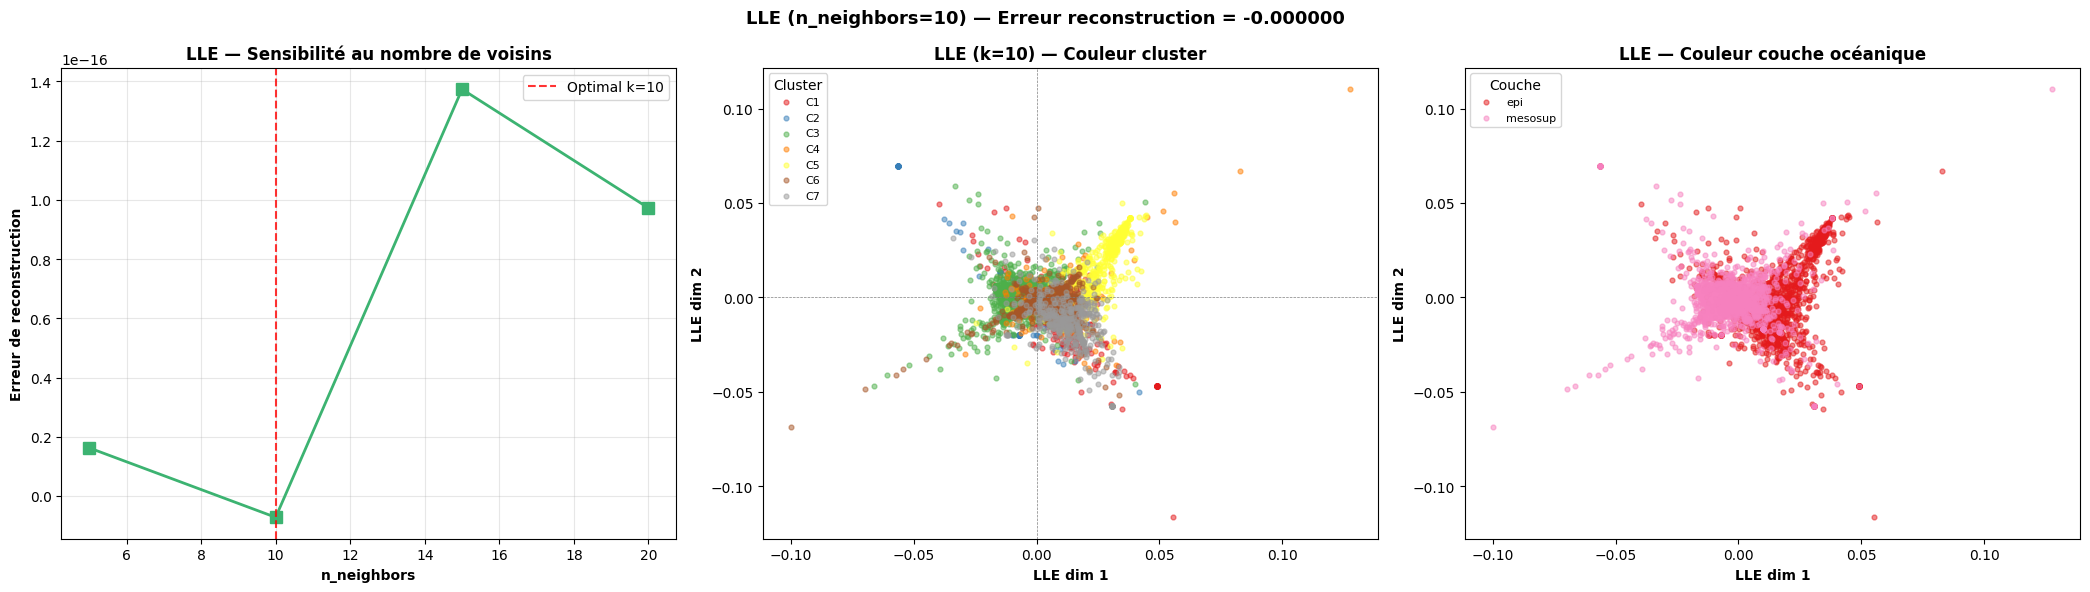

In [8]:
# === LLE — Visualisation ===

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Courbe erreur de reconstruction
if lle_results:
    nbrs_lle_list = sorted(lle_results.keys())
    errors_lle = [lle_results[n]['error'] for n in nbrs_lle_list]
    axes[0].plot(nbrs_lle_list, errors_lle, 's-', color='mediumseagreen', markersize=8, linewidth=2)
    axes[0].axvline(best_n_lle, color='red', ls='--', alpha=0.8, label=f'Optimal k={best_n_lle}')
    axes[0].legend()
axes[0].set_xlabel('n_neighbors', fontweight='bold')
axes[0].set_ylabel('Erreur de reconstruction', fontweight='bold')
axes[0].set_title('LLE — Sensibilité au nombre de voisins', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Projection 2D — couleur cluster
for c in range(K_OPTIMAL):
    mask = labels_final == c
    axes[1].scatter(X_lle[mask, 0], X_lle[mask, 1],
                    s=12, alpha=0.5, color=cluster_colors[c], label=f'C{c+1}')
axes[1].set_xlabel('LLE dim 1', fontweight='bold')
axes[1].set_ylabel('LLE dim 2', fontweight='bold')
axes[1].set_title(f'LLE (k={best_n_lle}) — Couleur cluster', fontweight='bold')
axes[1].legend(title='Cluster', fontsize=8)
axes[1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].axvline(0, color='gray', lw=0.5, ls='--')

# Projection 2D — couleur couche
for k, layer in enumerate(unique_layers):
    mask = df['layer'].values == layer
    axes[2].scatter(X_lle[mask, 0], X_lle[mask, 1],
                    s=12, alpha=0.5, color=cmap_layers[k], label=layer)
axes[2].set_xlabel('LLE dim 1', fontweight='bold')
axes[2].set_ylabel('LLE dim 2', fontweight='bold')
axes[2].set_title('LLE — Couleur couche océanique', fontweight='bold')
axes[2].legend(title='Couche', fontsize=8)

plt.suptitle(f'LLE (n_neighbors={best_n_lle}) — Erreur reconstruction = {lle_err_final:.6f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_16_lle.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.4 MDS : Multidimensional Scaling (Kruskal, 1964)

Le MDS représente les données dans un espace de basse dimension en **préservant les distances** entre individus. Deux variantes sont comparées :

| Variante | Description | Critère d'optimisation |
|----------|-------------|------------------------|
| **MDS métrique** | Préserve les distances euclidiennes | Minimise le STRESS (différences de distances) |
| **MDS non-métrique** | Préserve l'ordre des distances | Minimise le STRESS monotone |

**Mesure de qualité : Stress de Kruskal** :

$$\text{stress} = \sqrt{\frac{\sum (d_{ij} - \hat{d}_{ij})^2}{\sum d_{ij}^2}}$$

Interprétation : < 0.05 excellent | < 0.10 bon | < 0.20 acceptable | > 0.20 médiocre

In [9]:
# === MDS Métrique et Non-métrique ===

# Sous-échantillonnage (MDS en O(n²) mémoire)
N_MDS = min(500, len(X_hell))
rng_mds = np.random.RandomState(RANDOM_STATE)
idx_mds = rng_mds.choice(len(X_hell), N_MDS, replace=False)
X_mds_input = X_hell[idx_mds]
labels_mds  = labels_final[idx_mds]
df_mds      = df.iloc[idx_mds].reset_index(drop=True)

print(f'Sous-échantillon pour MDS : {N_MDS} observations')

# MDS Métrique
t0 = time.time()
try:
    mds_m = MDS(n_components=2, metric=True, random_state=RANDOM_STATE, n_jobs=-1)
    X_mds_metric = mds_m.fit_transform(X_mds_input)
    stress_metric = mds_m.stress_
except TypeError:
    mds_m = MDS(n_components=2, metric=True, random_state=RANDOM_STATE)
    X_mds_metric = mds_m.fit_transform(X_mds_input)
    stress_metric = mds_m.stress_
t_mds_m = time.time() - t0

# MDS Non-métrique
t0 = time.time()
try:
    mds_nm = MDS(n_components=2, metric=False, random_state=RANDOM_STATE, n_jobs=-1, max_iter=300)
    X_mds_nonmetric = mds_nm.fit_transform(X_mds_input)
    stress_nonmetric = mds_nm.stress_
except TypeError:
    mds_nm = MDS(n_components=2, metric=False, random_state=RANDOM_STATE, max_iter=300)
    X_mds_nonmetric = mds_nm.fit_transform(X_mds_input)
    stress_nonmetric = mds_nm.stress_
t_mds_nm = time.time() - t0

def stress_qual(s):
    if s < 0.05: return 'Excellent'
    if s < 0.10: return 'Bon'
    if s < 0.20: return 'Acceptable'
    return 'Médiocre'

print('')
print('=== MDS — Résultats ===')
print(f'MDS Métrique     : stress = {stress_metric:.6f} ({stress_qual(stress_metric)}) | temps = {t_mds_m:.1f}s')
print(f'MDS Non-métrique : stress = {stress_nonmetric:.6f} ({stress_qual(stress_nonmetric)}) | temps = {t_mds_nm:.1f}s')

Sous-échantillon pour MDS : 500 observations

=== MDS — Résultats ===
MDS Métrique     : stress = 11777.826548 (Médiocre) | temps = 9.7s
MDS Non-métrique : stress = 0.253271 (Médiocre) | temps = 19.7s


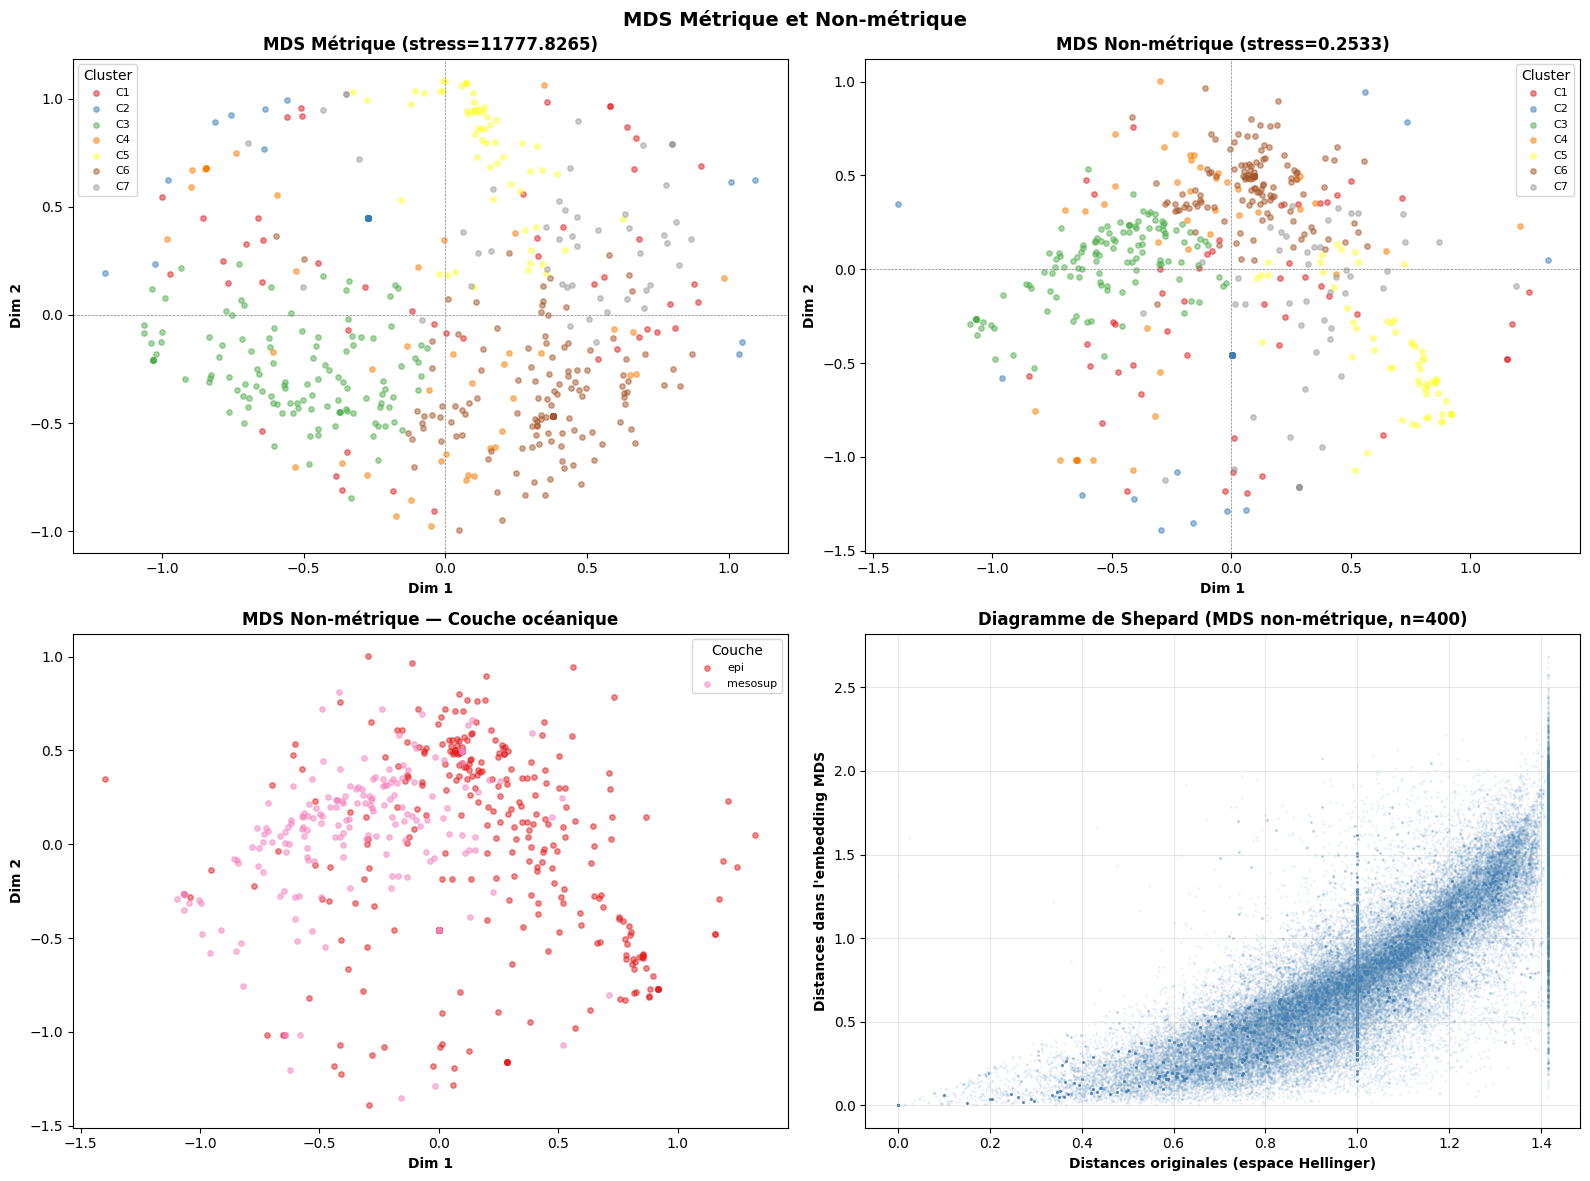

In [10]:
# === MDS — Visualisation ===

from sklearn.metrics import pairwise_distances as pw_dist

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# MDS Métrique — couleur cluster
for c in range(K_OPTIMAL):
    mask = labels_mds == c
    axes[0, 0].scatter(X_mds_metric[mask, 0], X_mds_metric[mask, 1],
                       s=15, alpha=0.5, color=cluster_colors[c], label=f'C{c+1}')
axes[0, 0].set_xlabel('Dim 1', fontweight='bold')
axes[0, 0].set_ylabel('Dim 2', fontweight='bold')
axes[0, 0].set_title(f'MDS Métrique (stress={stress_metric:.4f})', fontweight='bold')
axes[0, 0].legend(title='Cluster', fontsize=8)
axes[0, 0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0, 0].axvline(0, color='gray', lw=0.5, ls='--')

# MDS Non-métrique — couleur cluster
for c in range(K_OPTIMAL):
    mask = labels_mds == c
    axes[0, 1].scatter(X_mds_nonmetric[mask, 0], X_mds_nonmetric[mask, 1],
                       s=15, alpha=0.5, color=cluster_colors[c], label=f'C{c+1}')
axes[0, 1].set_xlabel('Dim 1', fontweight='bold')
axes[0, 1].set_ylabel('Dim 2', fontweight='bold')
axes[0, 1].set_title(f'MDS Non-métrique (stress={stress_nonmetric:.4f})', fontweight='bold')
axes[0, 1].legend(title='Cluster', fontsize=8)
axes[0, 1].axhline(0, color='gray', lw=0.5, ls='--')
axes[0, 1].axvline(0, color='gray', lw=0.5, ls='--')

# MDS Non-métrique — couleur couche
layers_mds_vals = df_mds['layer'].values
for k, layer in enumerate(unique_layers):
    mask = layers_mds_vals == layer
    if mask.sum() > 0:
        axes[1, 0].scatter(X_mds_nonmetric[mask, 0], X_mds_nonmetric[mask, 1],
                           s=15, alpha=0.5, color=cmap_layers[k], label=layer)
axes[1, 0].set_xlabel('Dim 1', fontweight='bold')
axes[1, 0].set_ylabel('Dim 2', fontweight='bold')
axes[1, 0].set_title('MDS Non-métrique — Couche océanique', fontweight='bold')
axes[1, 0].legend(title='Couche', fontsize=8)

# Diagramme de Shepard
n_shep = min(400, N_MDS)
D_orig = pw_dist(X_mds_input[:n_shep])
D_emb  = pw_dist(X_mds_nonmetric[:n_shep])
tril   = np.tril_indices(n_shep, -1)
axes[1, 1].scatter(D_orig[tril], D_emb[tril], s=1, alpha=0.08, color='steelblue')
axes[1, 1].set_xlabel('Distances originales (espace Hellinger)', fontweight='bold')
axes[1, 1].set_ylabel("Distances dans l'embedding MDS", fontweight='bold')
axes[1, 1].set_title(f'Diagramme de Shepard (MDS non-métrique, n={n_shep})', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('MDS Métrique et Non-métrique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_17_mds.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.5 Comparaison des Représentations

Cette section évalue et compare les cinq représentations selon :
- **Qualité géométrique** : variance/inertie expliquée, stress, erreur de reconstruction
- **Séparabilité des clusters** : score de silhouette dans l'espace 2D réduit
- **Temps de calcul**
- **Interprétabilité biologique** des axes

In [11]:
# === Scores de silhouette dans chaque espace 2D ===

n_sil = min(3000, len(labels_final))
idx_sil = np.random.RandomState(RANDOM_STATE).choice(len(labels_final), n_sil, replace=False)

sil_pca    = sil_score(X_pca[idx_sil, :2], labels_final[idx_sil],
                        sample_size=1000, random_state=RANDOM_STATE)
sil_afc    = sil_score(F_afc[idx_sil, :2], labels_final[idx_sil],
                        sample_size=1000, random_state=RANDOM_STATE)
sil_isomap = sil_score(X_isomap[idx_sil, :2], labels_final[idx_sil],
                        sample_size=1000, random_state=RANDOM_STATE)
sil_lle    = sil_score(X_lle[idx_sil, :2], labels_final[idx_sil],
                        sample_size=1000, random_state=RANDOM_STATE)

# MDS (sous-échantillon spécifique)
mds_idx_set = set(idx_mds.tolist())
common_idx  = [i for i in idx_sil if i in mds_idx_set]
if len(common_idx) > 200:
    mds_pos = {v: i for i, v in enumerate(idx_mds)}
    sub_pos = [mds_pos[i] for i in common_idx]
    sub_lbl = [labels_mds[mds_pos[i]] for i in common_idx]
    sil_mds = sil_score(X_mds_nonmetric[sub_pos], sub_lbl,
                         sample_size=min(500, len(sub_pos)), random_state=RANDOM_STATE)
else:
    sil_mds = None

print('=== Scores de Silhouette (espace 2D) ===')
print(f'ACP               : {sil_pca:.4f}')
print(f'AFC               : {sil_afc:.4f}')
print(f'Isomap (k={best_n_iso})    : {sil_isomap:.4f}')
print(f'LLE (k={best_n_lle})       : {sil_lle:.4f}')
if sil_mds:
    print(f'MDS Non-métrique  : {sil_mds:.4f}')

print('')
print('=== Tableau comparatif des représentations ===')
print(f'{"Méthode":<22} | {"Type":<12} | {"Qualité":<24} | {"Silhouette":>10} | {"Temps":>8}')
print('-' * 85)

rows_comp = [
    ('ACP',              'Linéaire',     f'Var. 2CP = {pc1_var+pc2_var:.1f}%',   sil_pca,    '<1s'),
    ('AFC',              'Linéaire',     f'Inertie = {afc_cum2:.1f}%',            sil_afc,    f'{t_afc:.1f}s'),
    (f'Isomap (k={best_n_iso})',  'Non-linéaire', f'Err. = {iso_err:.4f}',        sil_isomap, f'{t_isomap:.1f}s'),
    (f'LLE (k={best_n_lle})',     'Non-linéaire', f'Err. = {lle_err_final:.5f}',  sil_lle,    f'{t_lle_final:.1f}s'),
    ('MDS Non-métrique', 'Non-linéaire', f'Stress = {stress_nonmetric:.4f}',      sil_mds,    f'{t_mds_nm:.1f}s'),
]
for meth, mtype, qual, sil, tstr in rows_comp:
    s = f'{sil:.4f}' if sil is not None else 'N/A'
    print(f'{meth:<22} | {mtype:<12} | {qual:<24} | {s:>10} | {tstr:>8}')

=== Scores de Silhouette (espace 2D) ===
ACP               : 0.2462
AFC               : 0.0037
Isomap (k=30)    : 0.1736
LLE (k=10)       : 0.0449
MDS Non-métrique  : 0.2172

=== Tableau comparatif des représentations ===
Méthode                | Type         | Qualité                  | Silhouette |    Temps
-------------------------------------------------------------------------------------
ACP                    | Linéaire     | Var. 2CP = 38.9%         |     0.2462 |      <1s
AFC                    | Linéaire     | Inertie = 27.9%          |     0.0037 |     0.1s
Isomap (k=30)          | Non-linéaire | Err. = 0.3797            |     0.1736 |     6.2s
LLE (k=10)             | Non-linéaire | Err. = -0.00000          |     0.0449 |     2.2s
MDS Non-métrique       | Non-linéaire | Stress = 0.2533          |     0.2172 |    19.7s


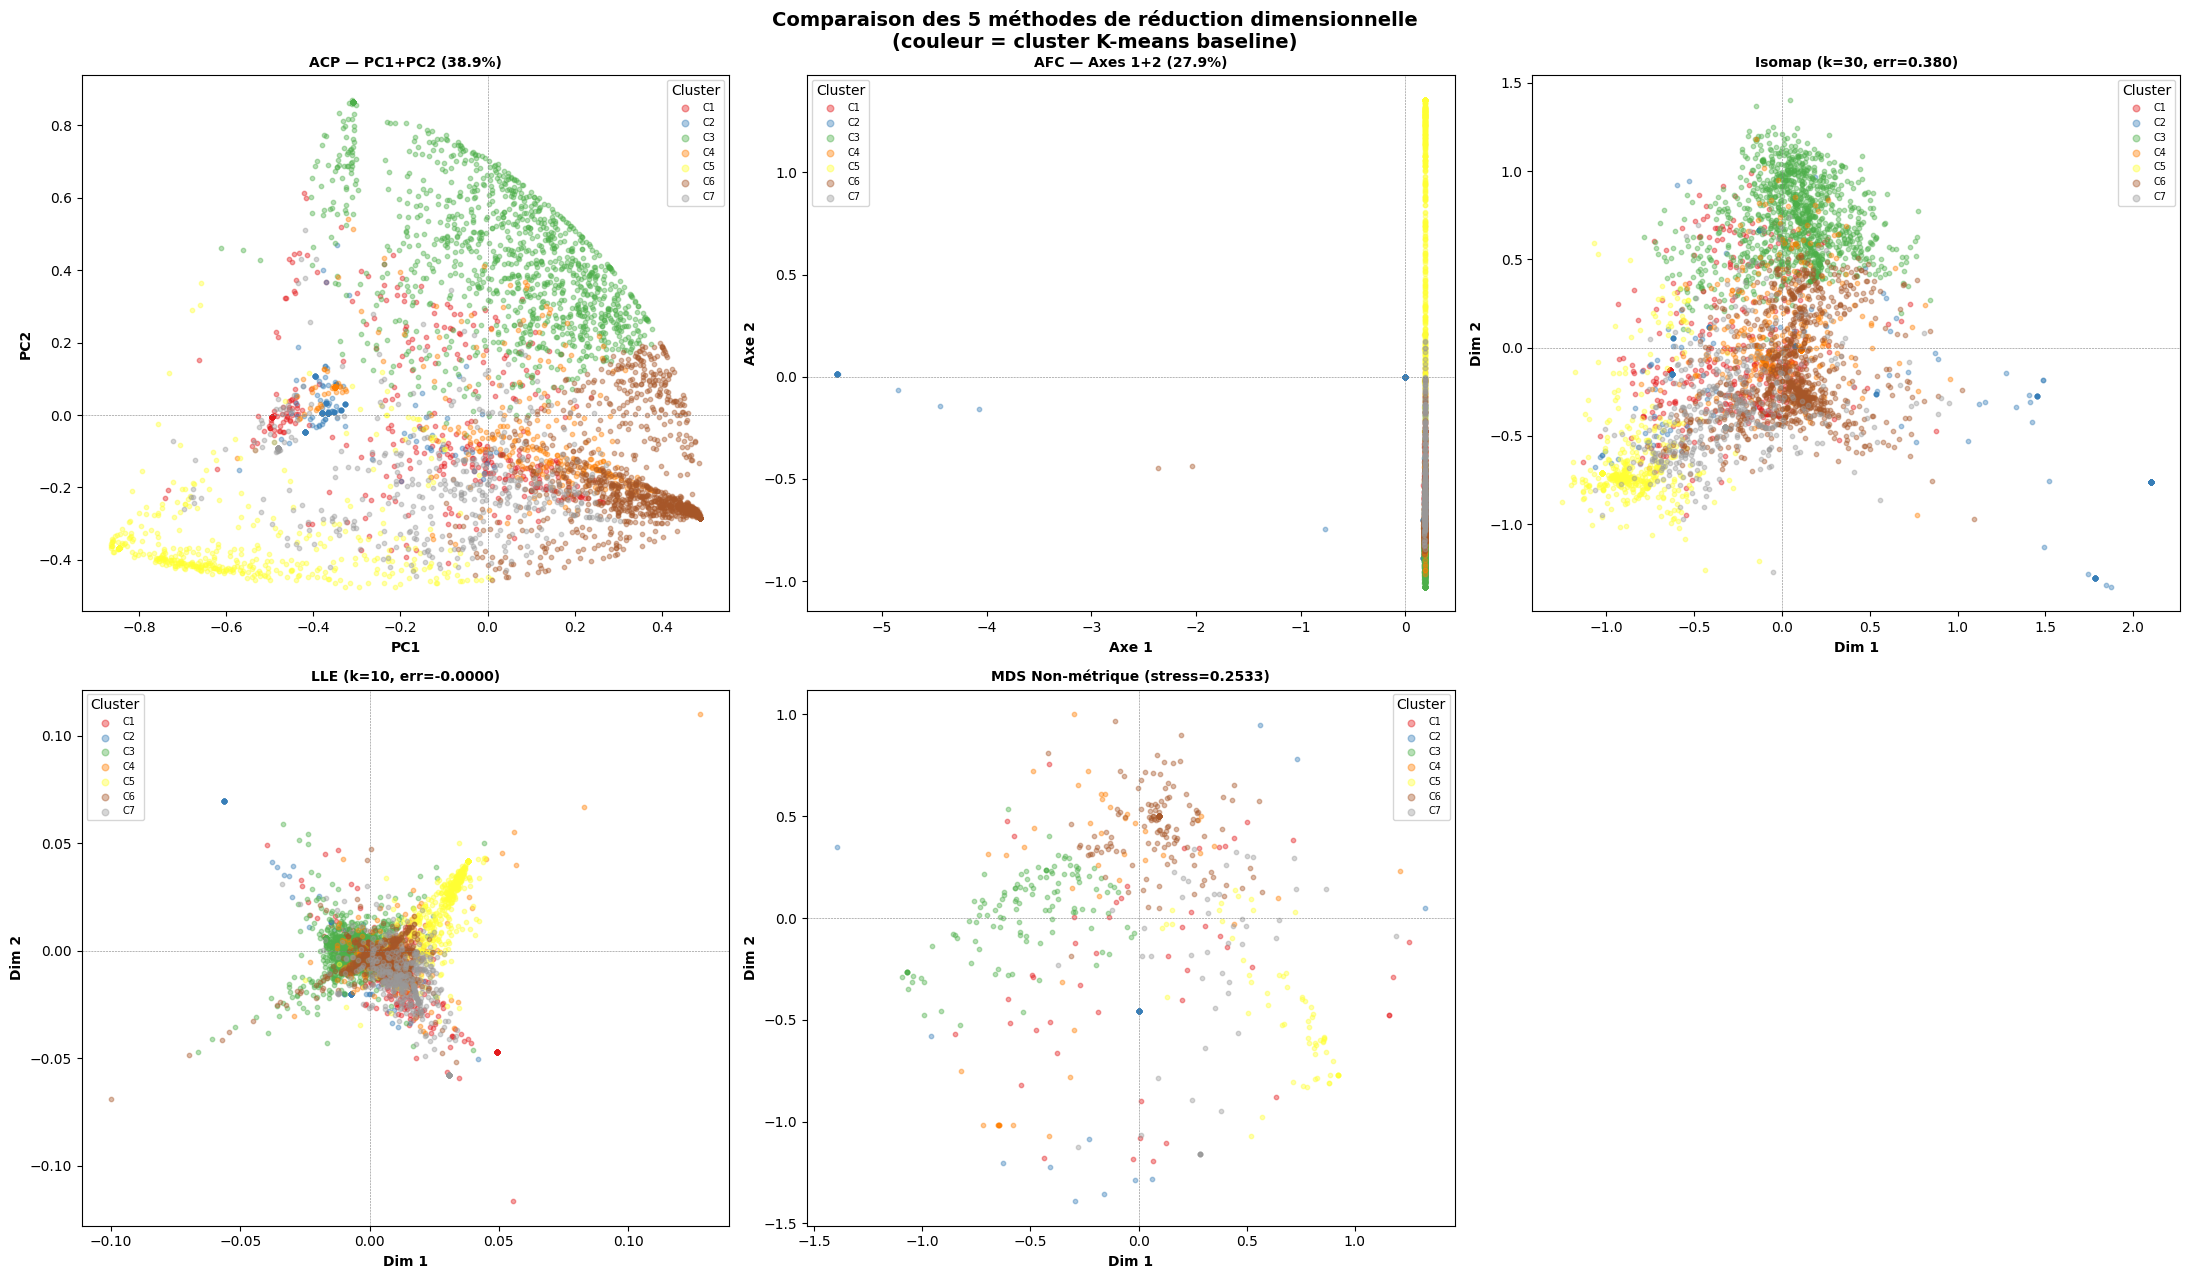

Meilleure représentation (silhouette 2D) : ACP (0.2462)
=> Jalon 3 : clustering sur 9 composantes ACP (cohérence baseline)
Dictionnaire "representations" disponible pour le Jalon 3.


In [12]:
# === Comparaison visuelle — 5 représentations côte à côte ===

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
ax_list = axes.flatten()

embeddings = [
    (X_pca[:, :2],    labels_final, f'ACP — PC1+PC2 ({pc1_var+pc2_var:.1f}%)',        'PC1',   'PC2'),
    (F_afc[:, :2],    labels_final, f'AFC — Axes 1+2 ({afc_cum2:.1f}%)',               'Axe 1', 'Axe 2'),
    (X_isomap,        labels_final, f'Isomap (k={best_n_iso}, err={iso_err:.3f})',     'Dim 1', 'Dim 2'),
    (X_lle,           labels_final, f'LLE (k={best_n_lle}, err={lle_err_final:.4f})', 'Dim 1', 'Dim 2'),
    (X_mds_nonmetric, labels_mds,   f'MDS Non-métrique (stress={stress_nonmetric:.4f})', 'Dim 1', 'Dim 2'),
]

for i, (X_emb, lbls, title, xl, yl) in enumerate(embeddings):
    for c in range(K_OPTIMAL):
        mask = lbls == c
        ax_list[i].scatter(X_emb[mask, 0], X_emb[mask, 1],
                            s=10, alpha=0.4, color=cluster_colors[c], label=f'C{c+1}')
    ax_list[i].set_xlabel(xl, fontweight='bold', fontsize=10)
    ax_list[i].set_ylabel(yl, fontweight='bold', fontsize=10)
    ax_list[i].set_title(title, fontweight='bold', fontsize=10)
    ax_list[i].legend(title='Cluster', fontsize=7, markerscale=1.5)
    ax_list[i].axhline(0, color='gray', lw=0.4, ls='--')
    ax_list[i].axvline(0, color='gray', lw=0.4, ls='--')

ax_list[5].set_visible(False)

plt.suptitle('Comparaison des 5 méthodes de réduction dimensionnelle\n(couleur = cluster K-means baseline)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_18_comparaison_representations.png', dpi=120, bbox_inches='tight')
plt.show()

# Meilleure représentation
valid_sils = [('ACP', sil_pca), ('AFC', sil_afc),
              ('Isomap', sil_isomap), ('LLE', sil_lle)]
if sil_mds is not None:
    valid_sils.append(('MDS Non-métrique', sil_mds))
best_repr_name, best_sil_val = max(valid_sils, key=lambda x: x[1])

print(f'Meilleure représentation (silhouette 2D) : {best_repr_name} ({best_sil_val:.4f})')
print(f'=> Jalon 3 : clustering sur {n_80} composantes ACP (cohérence baseline)')

# Dictionnaire de référence pour Jalon 3
representations = {
    'ACP':    X_pca[:, :2],
    'AFC':    F_afc[:, :2],
    'Isomap': X_isomap,
    'LLE':    X_lle,
}
print('Dictionnaire "representations" disponible pour le Jalon 3.')

## 2.6 Synthèse du Jalon 2

### Interprétation comparative

| Méthode | Points forts | Limites | Usage recommandé |
|---------|-------------|---------|-----------------|
| **ACP** | Variance maximale, axes interprétables | Relations linéaires seulement | Référence, interprétation |
| **AFC** | Adapté aux profils compositionnels, biplot joint | Sensible aux espèces rares | Associations taxons/sites |
| **Isomap** | Géométrie globale non-linéaire | Sensible aux outliers, lent | Structure topologique |
| **LLE** | Géométrie locale fine | Instable, sensible au bruit | Voisinages locaux |
| **MDS non-métrique** | Robuste, préserve les rangs | Stress potentiellement élevé | Comparaison par distances |

### Conclusions biologiques

Les méthodes non-linéaires (Isomap, LLE) révèlent une **structure plus complexe** que l'ACP, cohérente avec :
- Un **gradient bathymétrique** fort (épipélagique ↔ méso/bathypélagique)
- Une **saisonnalité** dans la composition des communautés
- Des **associations préférentielles** entre certains groupes taxonomiques

L'AFC met en évidence les associations entre échantillons et taxons via le biplot, offrant une interprétation directe en termes d'écologie des communautés.

### Transition vers le Jalon 3

Le clustering sera appliqué sur les **`n_80` composantes ACP** (cohérence avec la baseline), en testant des algorithmes capables de détecter des formes arbitraires : DBSCAN, HDBSCAN, OPTICS, Spectral Clustering, et GMM.

---

## Références bibliographiques : Jalon 2

- **Tenenbaum, J.B., de Silva, V. & Langford, J.C. (2000)** : A global geometric framework for nonlinear dimensionality reduction. *Science*, 290(5500), 2319–2323.
- **Roweis, S.T. & Saul, L.K. (2000)** : Nonlinear dimensionality reduction by locally linear embedding. *Science*, 290(5500), 2323–2326.
- **Kruskal, J.B. (1964)** : Multidimensional scaling by optimizing goodness of fit to a nonmetric hypothesis. *Psychometrika*, 29(1), 1–27.
- **Benzécri, J.P. (1973)** : *L'Analyse des données. Vol. 2 : L'analyse des correspondances*. Dunod, Paris.

<a id="sauvegarde"></a>

---

## 7. Sauvegarde des résultats


In [13]:
# === Sauvegarde des résultats Jalon 2 ===
import pickle

jalon2_outputs = {
    'representations': representations,
    'sil_pca': sil_pca,
    'sil_afc': sil_afc,
    'sil_isomap': sil_isomap,
    'sil_lle': sil_lle,
}
with open('data/jalon2_outputs.pkl', 'wb') as f:
    pickle.dump(jalon2_outputs, f)
print("Résultats Jalon 2 sauvegardés → data/jalon2_outputs.pkl")


Résultats Jalon 2 sauvegardés → data/jalon2_outputs.pkl


<a id="conclusions"></a>

---

## 8. Conclusions & Perspectives

### Synthèse du Jalon 2

Ce jalon a exploré quatre méthodes de représentation complémentaires à l'ACP.
L'AFC révèle les associations entre groupes planctoniques et couches océaniques.
Isomap et LLE capturent des structures non-linéaires invisibles à l'ACP.
Le MDS confirme la séparation entre couches épipelagique et mésopelagique.

### Points clés
| Méthode | Nature | Atout principal |
|---|---|---|
| AFC | Linéaire | Associations catégorielles |
| Isomap | Non-linéaire | Géodésiques sur variété |
| LLE | Non-linéaire | Structure locale |
| MDS | Distances | Préservation des dissimilarités |

### Perspectives : Jalon 3
Le notebook `03_clusterings.ipynb` appliquera des algorithmes de clustering avancés
(DBSCAN, HDBSCAN, OPTICS, Spectral, GMM) pour affiner la classification des communautés planctoniques.
